In [5]:
import numpy as np


def create_bigbird_attention_pattern(seq_len, window_size, num_global, num_random, seed=42):
    """
    Create a BigBird attention pattern combining local, global, and random attention.

    Args:
        seq_len: Length of the sequence
        window_size: Size of the sliding window (one-sided)
        num_global: Number of global tokens at the start
        num_random: Number of random attention connections per token
        seed: Random seed for reproducibility

    Returns:
        attention_mask: Binary mask of shape (seq_len, seq_len)
    """
    rng = np.random.default_rng(seed)
    mask = np.zeros((seq_len, seq_len), dtype=np.float32)

    # Component 1: Sliding window attention
    for i in range(seq_len):
        start = max(0, i - window_size)
        end = min(seq_len, i + window_size + 1)
        mask[i, start:end] = 1.0

    # Component 2: Global tokens (first num_global tokens)
    mask[:num_global, :] = 1.0  # Global tokens attend to all
    mask[:, :num_global] = 1.0  # All tokens attend to global

    # Component 3: Random attention
    for i in range(num_global, seq_len):
        # Get positions not already attended to
        local_start = max(0, i - window_size)
        local_end = min(seq_len, i + window_size + 1)

        # Candidate positions for random attention
        candidates = []
        for j in range(num_global, seq_len):
            if j < local_start or j >= local_end:
                candidates.append(j)

        # Sample random positions
        if len(candidates) > 0:
            num_to_sample = min(num_random, len(candidates))
            random_positions = rng.choice(
                candidates, size=num_to_sample, replace=False
            )
            mask[i, random_positions] = 1.0

    return mask

In [15]:
seq_len = 64
window_size = 3
num_global = 2
num_random = 3

bigbird_mask = create_bigbird_attention_pattern(
    seq_len, window_size, num_global, num_random
)

total_positions = seq_len * seq_len
attended_positions = bigbird_mask.sum()
sparsity = 1 - (attended_positions / total_positions)

print("BigBird attention pattern statistics:")
print(f"  Sequence length: {seq_len}")
print(f"  Window size: {window_size} (each side)")
print(f"  Global tokens: {num_global}")
print(f"  Random connections per token: {num_random}")
print()
print(f"  Total positions: {total_positions:,}")
print(f"  Attended positions: {int(attended_positions):,}")
print(f"  Sparsity: {sparsity:.1%}")

print()

BigBird attention pattern statistics:
  Sequence length: 64
  Window size: 3 (each side)
  Global tokens: 2
  Random connections per token: 3

  Total positions: 4,096
  Attended positions: 860
  Sparsity: 79.0%



In [13]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    exp_x = np.exp(x - x.max(axis=axis, keepdims=True))
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


class BigBirdAttention:
    """
    BigBird sparse attention implementation.

    Combines sliding window, global tokens, and random attention
    for O(n) complexity with strong theoretical guarantees.
    """

    def __init__(
        self, d_model, window_size=64, num_global=2, num_random=3, seed=None
    ):
        """
        Initialize BigBird attention.

        Args:
            d_model: Model dimension
            window_size: One-sided sliding window size
            num_global: Number of global tokens at sequence start
            num_random: Number of random attention connections per token
            seed: Random seed for reproducibility
        """
        self.d_model = d_model
        self.window_size = window_size
        self.num_global = num_global
        self.num_random = num_random
        self.seed = seed

        self.scale = 1.0 / np.sqrt(d_model)

        # Initialize projections with Xavier initialization
        self.W_Q = np.random.randn(d_model, d_model) * np.sqrt(
            2.0 / (2 * d_model)
        )
        self.W_K = np.random.randn(d_model, d_model) * np.sqrt(
            2.0 / (2 * d_model)
        )
        self.W_V = np.random.randn(d_model, d_model) * np.sqrt(
            2.0 / (2 * d_model)
        )
        self.W_O = np.random.randn(d_model, d_model) * np.sqrt(
            2.0 / (2 * d_model)
        )

    def _create_attention_mask(self, seq_len):
        """Create the BigBird attention pattern."""
        return create_bigbird_attention_pattern(
            seq_len,
            self.window_size,
            self.num_global,
            self.num_random,
            seed=self.seed,
        )

    def __call__(self, X):
        """
        Apply BigBird attention.

        Args:
            X: Input tensor of shape (seq_len, d_model)

        Returns:
            output: Attended representations (seq_len, d_model)
            attention_weights: Sparse attention weights (seq_len, seq_len)
        """
        seq_len = X.shape[0]

        # Project to Q, K, V
        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V

        # Compute full attention scores
        scores = (Q @ K.T) * self.scale

        # Apply BigBird mask
        mask = self._create_attention_mask(seq_len)
        masked_scores = np.where(mask > 0, scores, -1e9)

        # Softmax and aggregate
        attention_weights = softmax(masked_scores, axis=-1)

        # Zero out weights for masked positions
        attention_weights = attention_weights * mask

        # Compute output
        output = attention_weights @ V
        output = output @ self.W_O

        return output, attention_weights

In [16]:
d_model = 64
seq_len = 256

X = np.random.randn(seq_len, d_model)

bigbird = BigBirdAttention(
    d_model=d_model, window_size=8, num_global=4, num_random=5, seed=42
)

output, weights = bigbird(X)

nonzero_per_row = (weights > 0).sum(axis=1).mean()
weight_sparsity = 1 - (weights > 0).sum() / (seq_len * seq_len)

print("BigBird attention test:")
print(f"  Input shape: {X.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Attention weights shape: {weights.shape}")
print()
print("Attention statistics:")
print(f"  Non-zero weights per row: {nonzero_per_row:.1f}")
print(f"  Sparsity: {weight_sparsity:.1%}")
print()
print(f"Expected connections per token: 2*8 + 1 + 4 + 5 = {2*8 + 1 + 4 + 5}")

BigBird attention test:
  Input shape: (256, 64)
  Output shape: (256, 64)
  Attention weights shape: (256, 256)

Attention statistics:
  Non-zero weights per row: 29.3
  Sparsity: 88.5%

Expected connections per token: 2*8 + 1 + 4 + 5 = 26


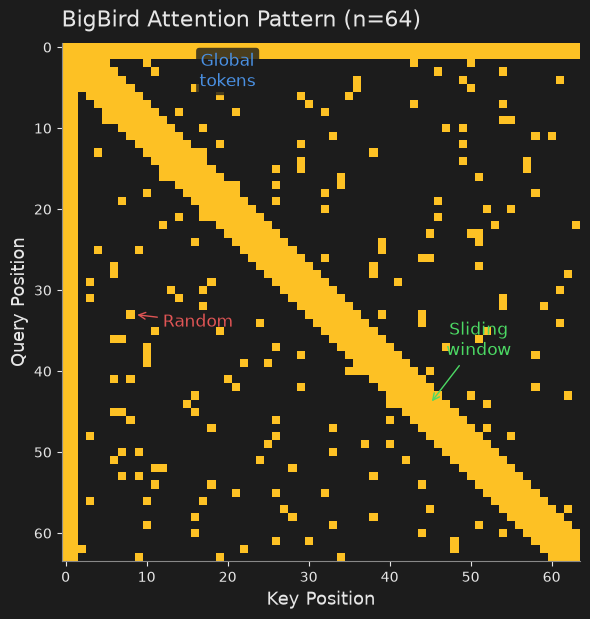

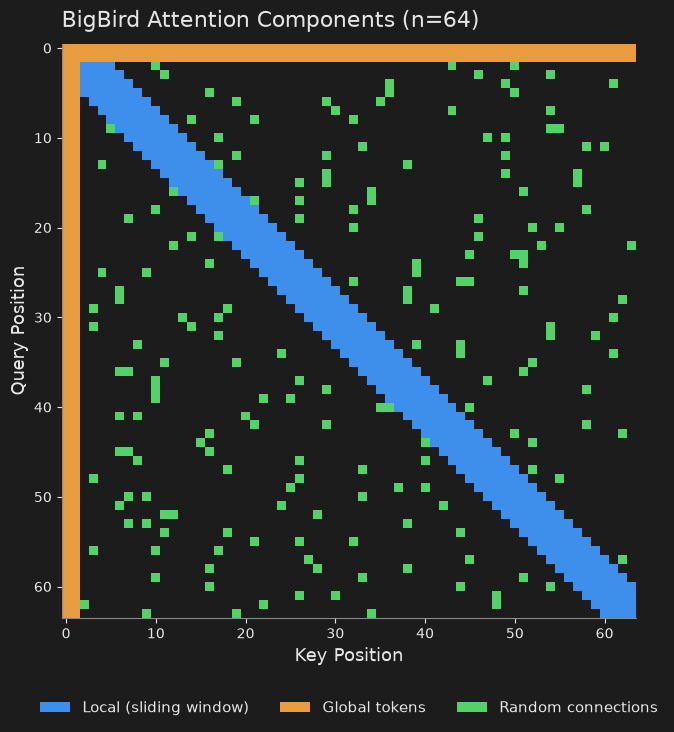

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ---------------- Settings ----------------
seq_len, window_size, num_global, num_random = 64, 3, 2, 3
mask = create_bigbird_attention_pattern(seq_len, window_size, num_global, num_random)

# ---------------- Theme ----------------
BG = "#1c1c1c"
FG = "#e6e6e6"
YELLOW = "#FDC124"
BLUE = "#3D8FEB"
ORANGE = "#E69C3F"
GREEN = "#55D16A"


def style_axes(ax, title):
    ax.set_title(title, color=FG, fontsize=16, loc="left", pad=12)
    ax.set_xlabel("Key Position", color=FG, fontsize=13)
    ax.set_ylabel("Query Position", color=FG, fontsize=13)
    ax.set_xticks(range(0, seq_len, 10))
    ax.set_yticks(range(0, seq_len, 10))
    ax.tick_params(colors=FG)
    ax.set_facecolor(BG)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color("#888888")


# =====================================================
# Graph 1: BigBird Attention Pattern
# =====================================================
fig1, ax1 = plt.subplots(figsize=(6, 6.3), facecolor=BG)
cmap1 = ListedColormap([BG, YELLOW])
ax1.imshow(mask, cmap=cmap1, vmin=0, vmax=1, interpolation="nearest")
style_axes(ax1, f"BigBird Attention Pattern (n={seq_len})")

# Annotations
ax1.text(20, 3, "Global\ntokens", color="#4A90E2", fontsize=12, ha="center", va="center",
         bbox=dict(boxstyle="round,pad=0.2", fc=BG, ec="none", alpha=0.8))
ax1.annotate("Random", xy=(8.5, 33), xytext=(12, 34.5), color="#E05555", fontsize=12,
             arrowprops=dict(arrowstyle="->", color="#E05555"))
ax1.annotate("Sliding\nwindow", xy=(45, 44), xytext=(51, 38), color="#4CD964",
             fontsize=12, ha="center",
             arrowprops=dict(arrowstyle="->", color="#4CD964"))

fig1.tight_layout()
fig1.savefig("bigbird_pattern.png", dpi=200, facecolor=BG)

# =====================================================
# Graph 2: BigBird Attention Components
# =====================================================
# Separate each component
local = np.zeros((seq_len, seq_len), dtype=bool)
for i in range(seq_len):
    local[i, max(0, i - window_size):min(seq_len, i + window_size + 1)] = True

glob = np.zeros((seq_len, seq_len), dtype=bool)
glob[:num_global, :] = True
glob[:, :num_global] = True

random_only = (mask > 0) & ~local & ~glob

# 0 = empty, 1 = local, 2 = global, 3 = random  (later ones overwrite earlier)
categories = np.zeros((seq_len, seq_len), dtype=int)
categories[random_only] = 3
categories[local] = 1
categories[glob] = 2

fig2, ax2 = plt.subplots(figsize=(7, 7.5), facecolor=BG)
cmap2 = ListedColormap([BG, BLUE, ORANGE, GREEN])
ax2.imshow(categories, cmap=cmap2, vmin=0, vmax=3, interpolation="nearest")
style_axes(ax2, f"BigBird Attention Components (n={seq_len})")

legend_items = [
    Patch(facecolor=BLUE, label="Local (sliding window)"),
    Patch(facecolor=ORANGE, label="Global tokens"),
    Patch(facecolor=GREEN, label="Random connections"),
]
leg = ax2.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, -0.12),
                 ncol=3, frameon=False, fontsize=11)
for text in leg.get_texts():
    text.set_color(FG)

fig2.tight_layout()
fig2.savefig("bigbird_components.png", dpi=200, facecolor=BG)

plt.show()

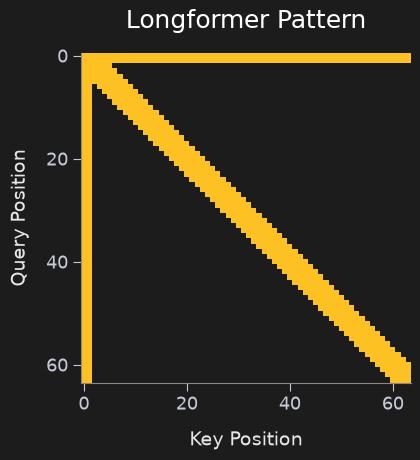

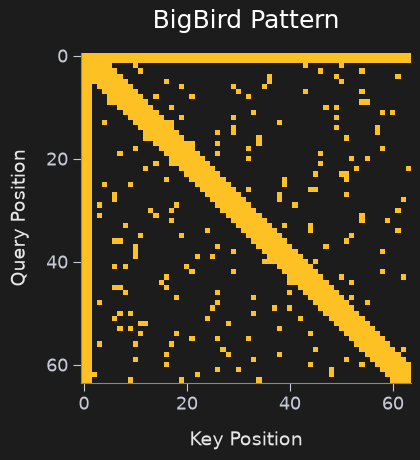

Saved: longformer_pattern.png, bigbird_pattern_small.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def create_longformer_pattern(seq_len, window_size, num_global):
    """Sliding window + global tokens (no random connections)."""
    mask = np.zeros((seq_len, seq_len), dtype=np.float32)
    for i in range(seq_len):
        mask[i, max(0, i - window_size):min(seq_len, i + window_size + 1)] = 1.0
    mask[:num_global, :] = 1.0
    mask[:, :num_global] = 1.0
    return mask

# ---------------- Settings ----------------
seq_len, window_size, num_global, num_random = 64, 3, 2, 3

BG = "#1c1c1c"
FG = "#e6e6e6"
TICK = "#c5cad6"
YELLOW = "#FDC124"


def plot_pattern(mask, title, filename):
    fig = plt.figure(figsize=(6.4, 5.33), facecolor=BG)
    ax = fig.add_axes([0.33, 0.22, 0.515, 0.62])  # square plot area, room for labels

    ax.imshow(mask, cmap=ListedColormap([BG, YELLOW]), vmin=0, vmax=1,
              interpolation="nearest")

    ax.set_title(title, color="white", fontsize=18, pad=18)
    ax.set_xlabel("Key Position", color=FG, fontsize=14, labelpad=12)
    ax.set_ylabel("Query Position", color=FG, fontsize=14, labelpad=12)
    ax.set_xticks([0, 20, 40, 60])
    ax.set_yticks([0, 20, 40, 60])
    ax.tick_params(colors=TICK, labelsize=13, length=6)
    ax.set_facecolor(BG)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("bottom", "left"):
        ax.spines[side].set_color("#888888")

    fig.savefig(filename, dpi=300, facecolor=BG)
    plt.show()
    plt.close(fig)


longformer_mask = create_longformer_pattern(seq_len, window_size, num_global)
bigbird_mask = create_bigbird_attention_pattern(seq_len, window_size, num_global, num_random)

plot_pattern(longformer_mask, "Longformer Pattern", "longformer_pattern.png")
plot_pattern(bigbird_mask, "BigBird Pattern", "bigbird_pattern_small.png")

print("Saved: longformer_pattern.png, bigbird_pattern_small.png")